ITAI 2376 - Deep Learning in AI
# A02: Comparative Analysis of Machine Learning & Deep Learning Tools and Frameworks


This notebook demonstrates development-workflow differences among TensorFlow, PyTorch, and fastai.

Demo 1 - TensorFlow vs. PyTorch

Demo 2 - Pytorch vs. fastai

# Demo 1 - TensorFlow vs PyTorch

In [39]:
# Load MNIST datasets

# TensorFlow / Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

print("TensorFlow training shape:", x_train.shape)
print("TensorFlow test shape:", x_test.shape)

# PyTorch
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("PyTorch training samples:", len(train_dataset))
print("PyTorch test samples:", len(test_dataset))

TensorFlow training shape: (60000, 28, 28)
TensorFlow test shape: (10000, 28, 28)
PyTorch training samples: 60000
PyTorch test samples: 10000


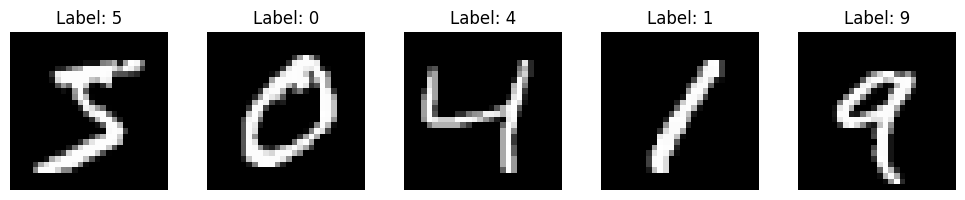

In [40]:
import matplotlib.pyplot as plt

# Display a few TensorFlow MNIST samples
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# TensorFlow/Keras Model

In [41]:
# Build a small neural network in TensorFlow/Keras

tf_model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

# Compile the model
tf_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
tf_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Train the TensorFlow/Keras model

tf_history = tf_model.fit(
    x_train,
    y_train,
    epochs=3,
    validation_split=0.1
)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9221 - loss: 0.2775 - val_accuracy: 0.9658 - val_loss: 0.1287
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9639 - loss: 0.1219 - val_accuracy: 0.9712 - val_loss: 0.0953
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9750 - loss: 0.0831 - val_accuracy: 0.9737 - val_loss: 0.0864


In [43]:
# Evaluate the TensorFlow/Keras model

tf_loss, tf_accuracy = tf_model.evaluate(x_test, y_test)

print(f"TensorFlow Test Loss: {tf_loss:.4f}")
print(f"TensorFlow Test Accuracy: {tf_accuracy:.4%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9729 - loss: 0.0894
TensorFlow Test Loss: 0.0894
TensorFlow Test Accuracy: 97.2900%


# PyTorch Model

In [44]:
# Build a comparable neural network in PyTorch

pt_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(pt_model.parameters(), lr=0.001)

print(pt_model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


In [45]:
# Train the PyTorch model

for epoch in range(3):
    pt_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = pt_model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/3 - "
        f"Loss: {epoch_loss:.4f} - "
        f"Accuracy: {epoch_accuracy:.4%}"
    )

Epoch 1/3 - Loss: 0.3366 - Accuracy: 90.9150%
Epoch 2/3 - Loss: 0.1535 - Accuracy: 95.5550%
Epoch 3/3 - Loss: 0.1084 - Accuracy: 96.8167%


In [46]:
# Evaluate the PyTorch model

pt_model.eval()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = pt_model(images)
        loss = loss_fn(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

pt_test_loss = test_loss / len(test_loader)
pt_test_accuracy = correct / total

print(f"PyTorch Test Loss: {pt_test_loss:.4f}")
print(f"PyTorch Test Accuracy: {pt_test_accuracy:.4%}")

PyTorch Test Loss: 0.1043
PyTorch Test Accuracy: 96.9600%


In [47]:
# Compare TensorFlow and PyTorch test results

print("TensorFlow vs. PyTorch Test Results")
print("-" * 40)
print(f"TensorFlow Accuracy: {tf_accuracy:.4%}")
print(f"TensorFlow Loss:     {tf_loss:.4f}")
print(f"PyTorch Accuracy:    {pt_test_accuracy:.4%}")
print(f"PyTorch Loss:        {pt_test_loss:.4f}")

TensorFlow vs. PyTorch Test Results
----------------------------------------
TensorFlow Accuracy: 97.2900%
TensorFlow Loss:     0.0894
PyTorch Accuracy:    96.9600%
PyTorch Loss:        0.1043


# Demo 1 Findings
Both models used a similar architecture and were trained for the same number of epochs on MNIST. Their test results were comparable, so this demonstration does not establish a clear performance winner. The more meaningful difference in this demonstration was the development workflow. TensorFlow/Keras handled most of the training process through the high-level fit() method, while PyTorch required the training loop to be written explicitly, including gradient calculation and optimizer updates. This illustrates the tradeoff between higher-level convenience and more direct control.

# Demo 2 - PyTorch vs fastai

In [48]:
# Import fastai for Demo 2

import fastai
from fastai.vision.all import *

print("fastai version:", fastai.__version__)

fastai version: 2.8.8


In [49]:
# Create a balanced 5,000-image MNIST subset
# 500 images from each digit class

path = untar_data(URLs.MNIST)

small_files = []

for digit in range(10):
    digit_files = get_image_files(path / "training" / str(digit))
    small_files += digit_files[:500]

print("Total images:", len(small_files))

Total images: 5000


In [50]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda _: small_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(28)
)

dls = dblock.dataloaders(path, bs=64)

In [51]:
# Build a fastai image classifier

learn = vision_learner(
    dls,
    resnet18,
    metrics=accuracy
)

In [52]:
learn.fine_tune(1)

epoch,train_loss,valid_loss,accuracy,time
0,2.196936,1.082182,0.660000,00:30


epoch,train_loss,valid_loss,accuracy,time
0,0.940199,0.589756,0.831000,01:02


NOTE: The fastai demonstration used a balanced 5,000-image subset of MNIST and one fine-tuning epoch to keep runtime manageable. Because this setup differs from the native PyTorch model, the accuracy results should not be interpreted as a direct performance comparison. The purpose of this demo is to illustrate the difference in development workflow and level of abstraction.

#Demo 2 Findings

The native PyTorch workflow required explicit setup for the model, loss function, optimizer, training loop, gradient calculation, and parameter updates. In contrast,fastai handled much of this through higher-level abstractions such as DataBlock, dataloaders(), vision_learner(), and fine_tune().

This demonstrates the main difference between the two tools: PyTorch provides more direct control over the training process, while fastai reduces boilerplate and simplifies common deep learning workflows. Because fastai is built on PyTorch, developers can begin with its higher-level API and still move toward lower-level PyTorch components when greater customization is needed.

# Overall Comparison

In [53]:
# Overall framework comparison table

import pandas as pd
from IPython.display import display

comparison = pd.DataFrame({
    "Framework": ["TensorFlow/Keras", "PyTorch", "fastai"],
    "Abstraction": ["High", "Lower", "Very high"],
    "Boilerplate": ["Low", "Higher", "Very low"],
    "Developer Control": [
        "High, with abstraction",
        "High",
        "High-level by default; PyTorch underneath"
    ]
})

styled_table = (
    comparison.style
    .set_properties(
        subset=["Abstraction", "Boilerplate", "Developer Control"],
        **{"text-align": "center"}
    )
    .set_properties(
        subset=["Framework"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid #888"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #888"),
                ("padding", "8px")
            ]
        }
    ])
    .hide(axis="index")
)

display(styled_table)

Framework,Abstraction,Boilerplate,Developer Control
TensorFlow/Keras,High,Low,"High, with abstraction"
PyTorch,Lower,Higher,High
fastai,Very high,Very low,High-level by default; PyTorch underneath


# Conclusion
These demonstrations support the comparative findings from the research reports. TensorFlow/Keras and fastai simplify development through higher-level APIs, while PyTorch exposes more of the training process directly. The choice among them depends less on which framework is universally better and more on how much abstraction, flexibility, and direct control a project requires.